In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/consumption/1pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-24 23:10:00,-0.308303,-0.226107
2017-11-24 23:20:00,-0.403297,-0.334117
2017-11-24 23:30:00,-0.525433,-0.437983
2017-11-24 23:40:00,-0.616186,-0.576965
2017-11-24 23:50:00,-0.689976,-0.654797


In [3]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/consumption/1pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-24 23:10:00,-0.308303,-0.274257
2017-11-24 23:20:00,-0.403297,-0.372234
2017-11-24 23:30:00,-0.525433,-0.478073
2017-11-24 23:40:00,-0.616186,-0.613733
2017-11-24 23:50:00,-0.689976,-0.704881


In [4]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/consumption/1pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-24 23:10:00,-0.308303,-0.269653
2017-11-24 23:20:00,-0.403297,-0.371927
2017-11-24 23:30:00,-0.525433,-0.478313
2017-11-24 23:40:00,-0.616186,-0.620097
2017-11-24 23:50:00,-0.689976,-0.708124


In [5]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.197553
2017-11-25 01:10:00,-1.293020,-1.242730
2017-11-25 01:20:00,-1.333732,-1.339002
2017-11-25 01:30:00,-1.353240,-1.385698
2017-11-25 01:40:00,-1.345607,-1.403491


In [6]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.181835
2017-11-25 01:10:00,-1.293020,-1.250166
2017-11-25 01:20:00,-1.333732,-1.331410
2017-11-25 01:30:00,-1.353240,-1.404249
2017-11-25 01:40:00,-1.345607,-1.427199


In [7]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/1paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-23 22:50:00,-0.158178,-0.159813
2017-11-23 23:00:00,-0.311695,-0.288840
2017-11-23 23:10:00,-0.391423,-0.454973
2017-11-23 23:20:00,-0.466909,-0.499011
2017-11-23 23:30:00,-0.561055,-0.571243


In [8]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])



In [9]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-23 22:50:00,NaN,NaN,NaN,NaN,NaN,0.001635
2017-11-23 23:00:00,NaN,NaN,NaN,NaN,NaN,-0.022855
2017-11-23 23:10:00,NaN,NaN,NaN,NaN,NaN,0.063551
2017-11-23 23:20:00,NaN,NaN,NaN,NaN,NaN,0.032102
2017-11-23 23:30:00,NaN,NaN,NaN,NaN,NaN,0.010188


In [10]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:00:00,-0.031289,-0.002781,-0.000549,0.012249,-0.003468,-0.013691
2017-11-25 01:10:00,-0.095878,-0.076515,-0.075618,-0.050290,-0.042855,-0.075970
2017-11-25 01:20:00,0.027017,-0.008974,-0.001642,0.005270,-0.002323,0.006859
2017-11-25 01:30:00,-0.011162,0.002153,0.004866,0.032458,0.051009,0.002998
2017-11-25 01:40:00,0.010030,0.013443,0.026070,0.057885,0.081593,0.027433


Muestra aleatoria

In [11]:
final = final.sample(frac=0.10, random_state=42)

In [12]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [13]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


6.663116285461082e-101


In [14]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


4.28674526713057e-100


In [15]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


1.726223437058407e-100


In [16]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


4.3876670116345207e-94


In [17]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


1.1481600251676849e-93


In [18]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


5.066406324789479e-88


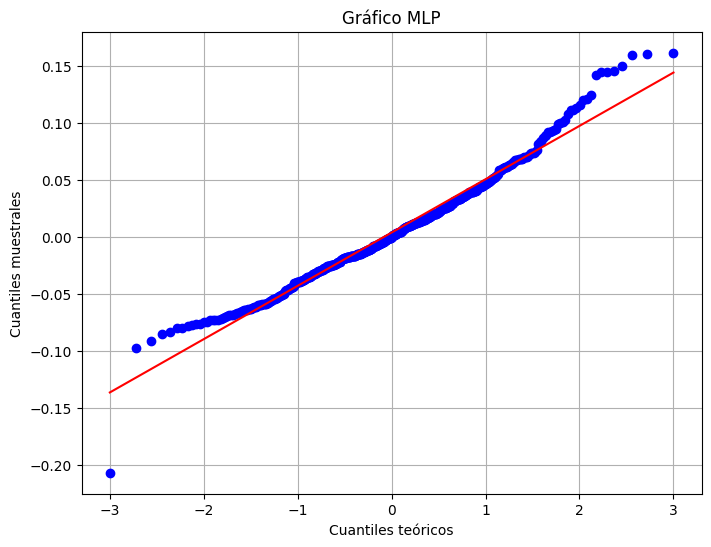

In [19]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

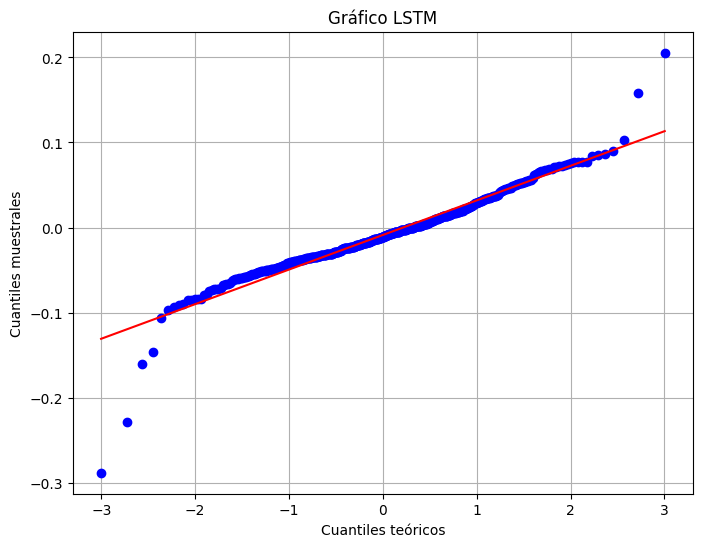

In [20]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

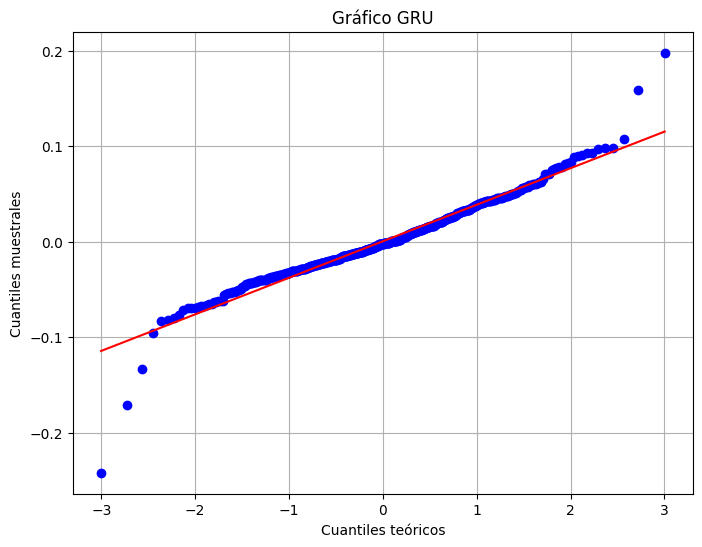

In [21]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

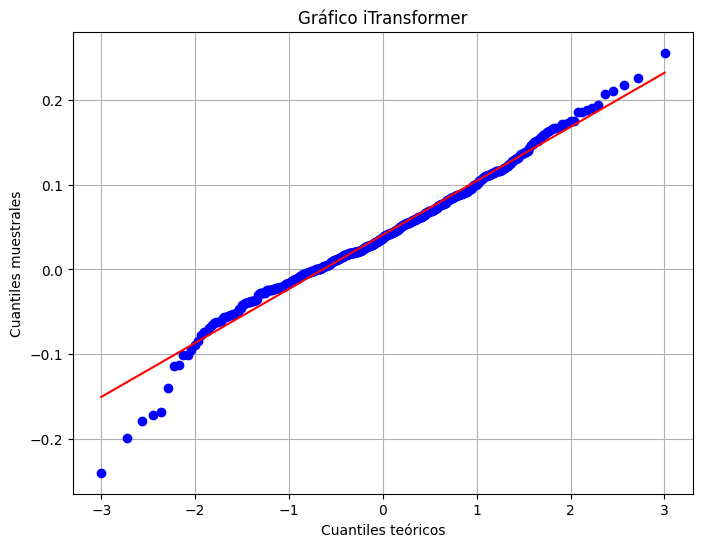

In [22]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

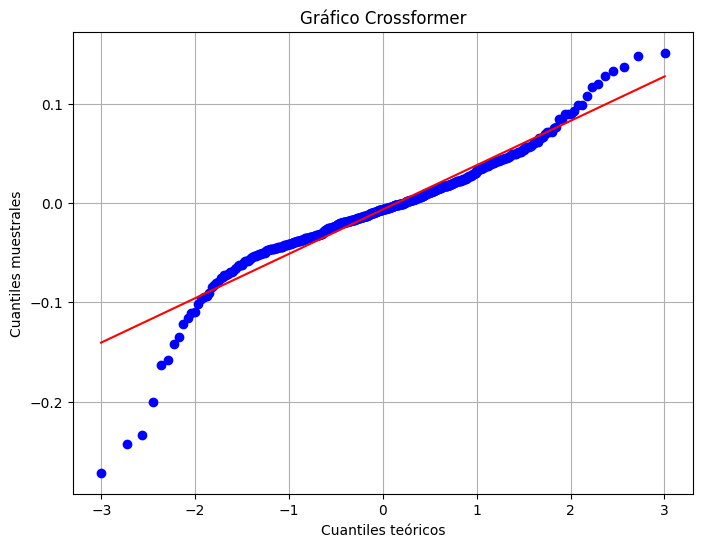

In [23]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

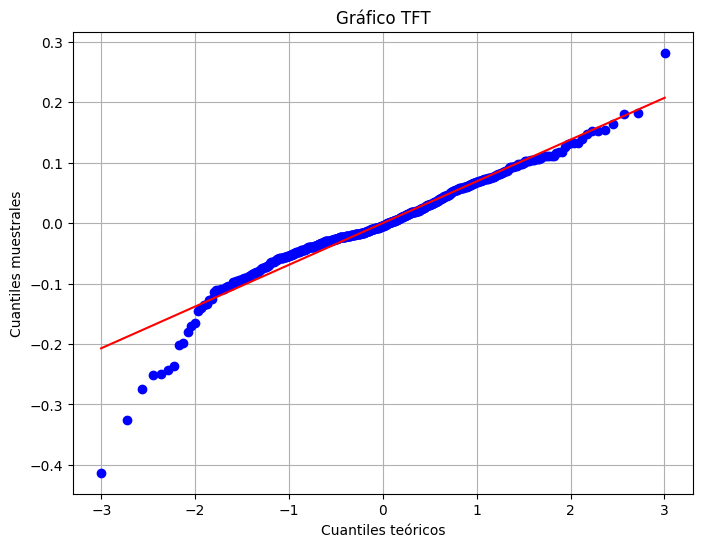

In [24]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [25]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

7.0993460184507315e-130


In [26]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00000,0.00000,0.00000
1,MLP vs GRU,0.00369,0.05537,0.01477
2,MLP vs Crossformer,0.00001,0.00008,0.00004
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.69431,1.00000,1.00000
5,LSTM vs GRU,0.00000,0.00000,0.00000
6,LSTM vs Crossformer,0.00020,0.00299,0.00100
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.00000,0.00006,0.00003
9,GRU vs Crossformer,0.00014,0.00211,0.00084
